In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("scaler_hashed_for_students.csv")
pos_mapping = pd.read_csv("scaler_job_positions_mapping VX.csv")

In [70]:
df.head()

,company_hash,orgyear,ctc,job_position,ctc_updated_year,experience,Designation,Class,Tier,kmeans_cluster
0,czniswwz sucsk,2016.0,1100000,Other,2020.0,10.0,3,1,2,1
1,oznskulz subilihh nshswzc,2018.0,449999,FullStack Engineer,2019.0,8.0,3,3,3,0
2,faulwklwsl ks,2015.0,2000000,Backend Engineer,2020.0,11.0,3,3,3,3
3,wirijzcsk,2017.0,700000,Backend Engineer,2019.0,9.0,3,3,3,0
4,osbw toidj,2017.0,1400000,FullStack Engineer,2019.0,9.0,3,1,1,1


In [ ]:
df.info()

In [ ]:
df.isna().sum()

In [ ]:
print(df['orgyear'].value_counts())

In [ ]:
print(df['ctc'].value_counts())

In [ ]:
df['ctc'].sort_values(ascending=False).head(20)

In [ ]:
df.loc[22386]

In [ ]:
df['ctc'].sort_values().head(20)

In [ ]:
df['ctc'].mean()

In [ ]:
df['ctc'].median()

In [ ]:
#df["company_hash"].fillna("Unknown", inplace=True)
df.fillna({"company_hash": "Unknown"}, inplace=True)
df.fillna({"job_position": "Unknown"}, inplace=True)

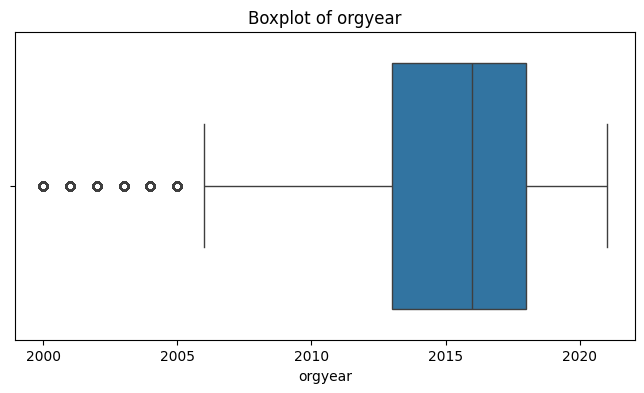

In [71]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["orgyear"])
plt.title("Boxplot of orgyear")
plt.show()

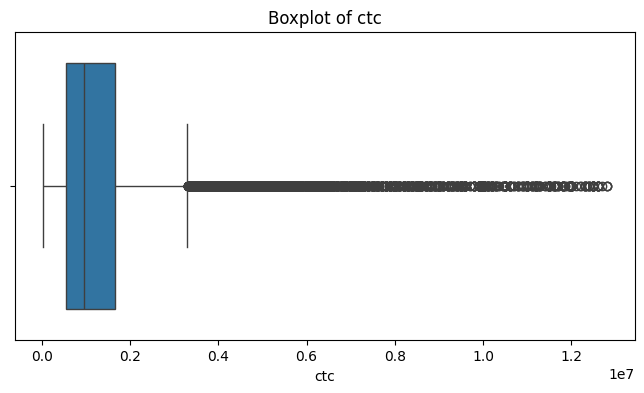

In [72]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["ctc"])
plt.title("Boxplot of ctc")
plt.show()

In [ ]:
df['ctc'].describe(percentiles=[.01, .05, .25, .5, .75, .9, .95, .99])

In [ ]:
df[df['ctc'] < 10000][['ctc','company_hash','job_position']].head(10)

In [ ]:
df[df['ctc'] > 30000000][['ctc','company_hash','job_position']].head(10)

In [ ]:
df.info()

In [ ]:
df = df[(df['ctc'] >= 30000) & (df['ctc'] < 13000000)]

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["ctc"])
plt.title("Boxplot of ctc")
plt.show()

In [ ]:
df.loc[(df["orgyear"] < 2000) | (df["orgyear"] > 2025), "orgyear"] = np.nan

In [ ]:
sns.boxplot(x=df["orgyear"].dropna())
plt.title("Boxplot of orgyear (after cleaning)")
plt.show()

In [ ]:
median_year = df["orgyear"].median()
df["orgyear"] = df["orgyear"].fillna(median_year)

df = df[df["orgyear"] <= df["ctc_updated_year"]]
df = df.reset_index(drop=True)

In [ ]:
df.info()

In [ ]:
df.duplicated().sum()

In [ ]:
df['experience'] = df['orgyear'].apply(lambda x: 2026-x)
df.head()

In [ ]:
designation_stats = df.groupby(
    ['company_hash', 'job_position', 'experience']
)['ctc'].describe().reset_index()

In [ ]:
df = df.merge(
    designation_stats,
    on=['company_hash', 'job_position', 'experience'],
    how='left',
    suffixes=('', '_designation')
)

In [ ]:
df.head()

In [ ]:
df.columns


In [ ]:
def designation_flag(row):
    if row['ctc'] > row['75%']:
        return 1
    elif row['ctc'] > row['50%'] and row['ctc'] <= row['75%']:
        return 2
    else:
        return 3

df['Designation'] = df.apply(designation_flag, axis=1)

In [ ]:
class_stats = df.groupby(
    ['company_hash', 'job_position']
)['ctc'].describe().reset_index()

In [ ]:
df = df.merge(
    class_stats,
    on=['company_hash', 'job_position'],
    how='left',
    suffixes=('', '_class')
)

In [ ]:
df.columns

In [ ]:
def class_flag(row):
    if row['ctc'] > row['75%_class']:
        return 1
    elif row['ctc'] > row['50%_class'] and row['ctc'] <= row['75%_class']:
        return 2
    else:
        return 3

df['Class'] = df.apply(class_flag, axis=1)

In [ ]:
tier_stats = df.groupby(
    ['company_hash']
)['ctc'].describe().reset_index()

In [ ]:
df = df.merge(
    tier_stats,
    on=['company_hash'],
    how='left',
    suffixes=('', '_tier')
)

In [ ]:
df.columns

In [ ]:
def tier_flag(row):
    if row['ctc'] > row['75%_tier']:
        return 1
    elif row['ctc'] > row['50%_tier'] and row['ctc'] <= row['75%_tier']:
        return 2
    else:
        return 3

df['Tier'] = df.apply(tier_flag, axis=1)

In [ ]:
features = ['company_hash', 'orgyear', 'ctc', 'job_position', 'ctc_updated_year', 'experience', 'Designation', 'Class', 'Tier']

In [ ]:
df = df[features]

In [ ]:
df.head()

In [ ]:
df.info()

**Top 10 employees (earning more than most of the employees in the company) - Tier 1**

In [ ]:
top10_tier1 = df[df['Tier'] == 1].sort_values(by='ctc', ascending=False).head(10)
top10_tier1

**Top 10 employees of data science in each company earning more than their peers - Class 1**

In [ ]:
top10_ds_each_company = (
    df[(df['job_position'] == 'Data Scientist') & (df['Class'] == 1)]
    .sort_values(['company_hash','ctc'], ascending=[True, False])
    .groupby('company_hash')
    .head(10)
)

top10_ds_each_company

**Bottom 10 employees of data science in each company earning less than their peers - Class 3**

In [ ]:
bottom10_ds_each_company = (
    df[(df['job_position'] == 'Data Scientist') & (df['Class'] == 3)]
    .sort_values(['company_hash','ctc'], ascending=[True, True])
    .groupby('company_hash')
    .head(10)
)

bottom10_ds_each_company

**Bottom 10 employees (earning less than most of the employees in the company)- Tier 3**

In [ ]:
bottom10_tier3 = df[df['Tier'] == 3].sort_values(by='ctc', ascending=True).head(10)
bottom10_tier3

**Top 10 employees in each company - X department - having 5/6/7 years of experience earning more than their peers - Tier X**

In [ ]:
top10_exp_5_6_7 = (
    df[(df['job_position'] == 'Data Scientist') & (df['experience'].isin([5,6,7])) & (df['Tier'] == 1)]
    .sort_values(['company_hash','ctc'], ascending=[True, False])
    .groupby('company_hash')
    .head(10)
)

top10_exp_5_6_7

**Top 10 companies (based on their CTC)**

In [ ]:
top10_companies = (
    df.groupby('company_hash')['ctc']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top10_companies

**Top 2 positions in every company (based on their CTC)**

In [ ]:
top2_positions_each_company = (
    df.groupby(['company_hash','job_position'])['ctc']
    .mean()
    .reset_index()
    .sort_values(['company_hash','ctc'], ascending=[True, False])
    .groupby('company_hash')
    .head(2)
)

top2_positions_each_company

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df['company_hash'].nunique()

In [ ]:
df['job_position'].nunique()

In [ ]:
features = ['ctc', 'experience', 'Tier', 'Class', 'Designation']
df_cluster = df[features].copy()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

**Checking clustering tendency**

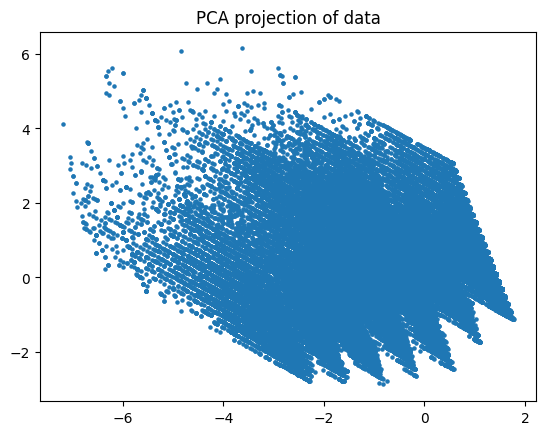

In [73]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], s=5)
plt.title("PCA projection of data")
plt.show()

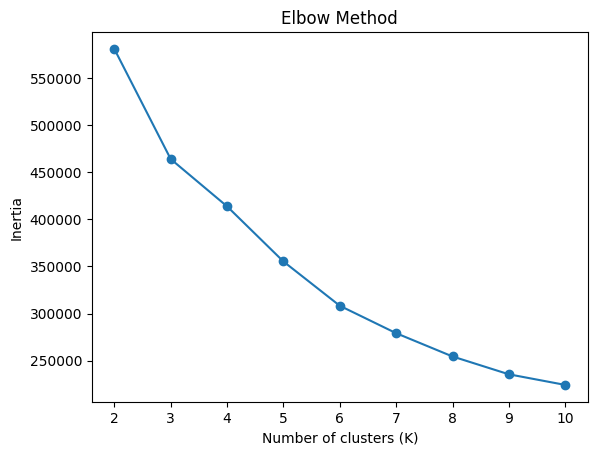

In [74]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=6, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
df.head()

In [ ]:
df_sample = df_cluster.sample(1000, random_state=42)
X_sample = StandardScaler().fit_transform(df_sample)

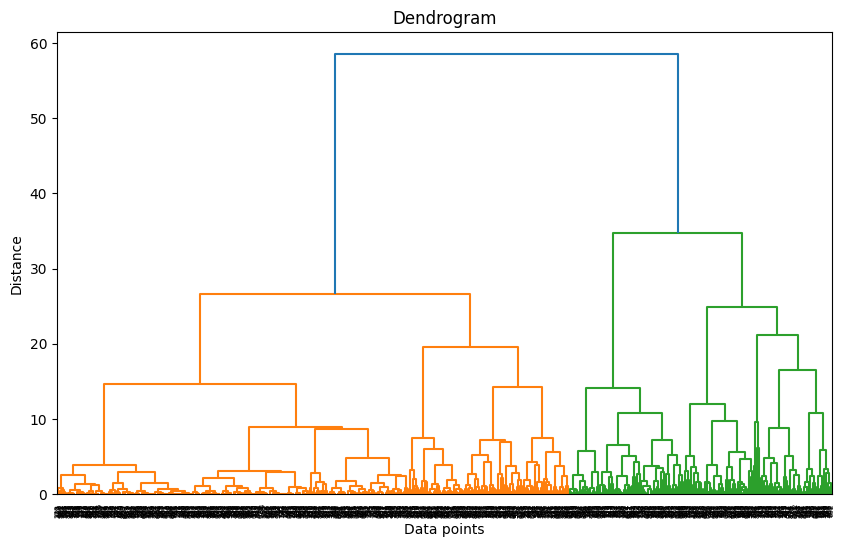

In [75]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(10,6))
dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Data points")
plt.ylabel("Distance")
plt.show()

In [ ]:
from scipy.cluster.hierarchy import fcluster

clusters = fcluster(Z, t=5, criterion='maxclust')
df_sample['hier_cluster'] = clusters

In [ ]:
df_sample.head()

In [ ]:
df.groupby('kmeans_cluster')[['ctc','experience','Tier','Class','Designation']].mean()

<Axes: xlabel='experience', ylabel='ctc'>

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


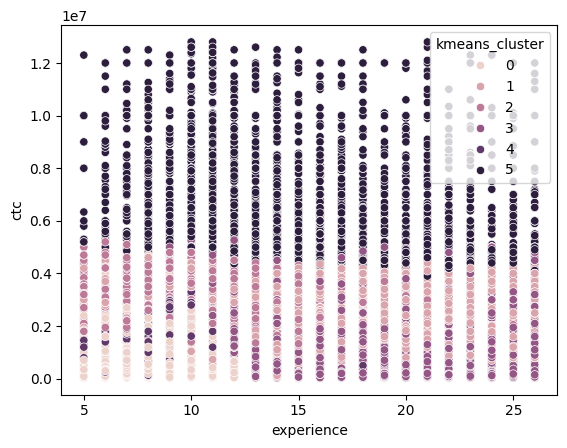

In [76]:
sns.scatterplot(data=df, x='experience', y='ctc', hue='kmeans_cluster')

# **Business Insights**



*   Salary distribution among employees shows significant variation even within the same experience level, indicating that salary is influenced not only by experience but also by company, role, and technical skills.
*   Clustering analysis reveals distinct salary tiers among employees, suggesting natural segmentation of professionals based on compensation levels.


*   A large number of companies are represented in the dataset, but only a small subset appears to offer significantly higher compensation packages.
*   Certain job roles consistently show higher median salaries compared to others, indicating strong demand for specialized technical roles.


*   The dataset indicates that high salaries can be achieved even with relatively lower experience when professionals possess the right skills or work in high-paying companies.







# **Business Recommendations**




*   Scaler should design targeted learning programs based on salary tiers and career stages to better support learner progression.
*   The company should strengthen partnerships with high-paying companies identified in the dataset to improve placement opportunities for learners.


*   Scaler should emphasize high-demand technical roles such as machine learning, backend engineering, and distributed systems in its curriculum.
*   Marketing efforts should highlight successful career transitions and salary growth stories to attract more professionals to the platform.